# The equilibrium, recomputed

This redoes [`../Equilibrium_Analysis.ipynb`](../Equilibrium_Analysis.ipynb),
which is where the `stage_test` mixture in `../Code.pl` comes from. What that
derivation did is quoted below precisely enough to check the criticism against
it, and nothing here edits it.

**The conclusion it reached still stands.** The strategy called `stage_test`
does outscore the Nash equilibrium when the two play each other, and the numbers
below reproduce the original's 3.5552 against 3.1521 exactly.

**What did not work is how it was found.** The original minimised the sum of
squared payoff gradients, with the comment *"zero at a stationary (Nash)
point"*. On a simplex that is the wrong condition. Player 1's payoff is linear
in their own strategy, so the gradient is constant and is never zero unless
every action pays zero. Minimising its norm therefore searches for the
strategies that pay least, which is why the original printed
`Stationarity residual: 80.89` under a success tick, and why on Battle of the
Sexes it returned a point that is none of the three equilibria and pays both
players less than all of them.

The right condition on a simplex is that the payoff vector is **flat across the
actions actually played**, with nothing unplayed paying more. Equivalently the
regret `max_i (A y)_i − x'A y` is zero for both players. That is what is used
here.

In [1]:
import numpy as np
import nashpy as nash
from fractions import Fraction
from scipy.optimize import linprog
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
np.set_printoptions(precision=4, suppress=True)

## The game

Two players pick an integer from 1 to 5 at the same time. If the picks differ by
exactly one, the player who picked the **smaller** number takes the sum and the
other takes nothing. Otherwise each simply scores the number they picked. The
asymmetry is what makes it interesting: undercutting by one is rewarded, so
every number invites being undercut.

In [2]:
def build_game(strategies=(1, 2, 3, 4, 5)):
    n = len(strategies)
    U1, U2 = np.zeros((n, n)), np.zeros((n, n))
    for i, a in enumerate(strategies):
        for j, b in enumerate(strategies):
            if abs(a - b) == 1:
                U1[i, j], U2[i, j] = (a + b, 0) if a < b else (0, a + b)
            else:
                U1[i, j], U2[i, j] = a, b
    return U1, U2

U1, U2 = build_game()
print("player 1's payoffs, rows are player 1's pick:")
print(U1.astype(int))

player 1's payoffs, rows are player 1's pick:
[[1 3 1 1 1]
 [0 2 5 2 2]
 [3 0 3 7 3]
 [4 4 0 4 9]
 [5 5 5 0 5]]


## The condition the original should have used

`regret` is zero exactly at a best response, and a pair is a Nash equilibrium
when both regrets are zero. This is a check, not a search: it takes a candidate
and tells you whether it qualifies.

In [3]:
def regret(x, y, U1, U2):
    """How much each player could gain by deviating. Zero at a best response."""
    return (U1 @ y).max() - x @ U1 @ y, (U2.T @ x).max() - x @ U2 @ y

def is_nash(x, y, U1, U2, tol=1e-8):
    return max(regret(x, y, U1, U2)) < tol

## Validate it where the answer is already known

Battle of the Sexes and the Prisoner's Dilemma have textbook solutions, and
NashPy enumerates them. This is the step the original skipped: it ran on these
two games, got a wrong answer on the first and a right answer on the second for
the wrong reason, and reported neither.

In [4]:
def check_known_game(name, A, B, original_answer=None):
    print(f"--- {name} ---")
    for x, y in nash.Game(A, B).vertex_enumeration():
        r = regret(x, y, A, B)
        print(f"  equilibrium x={np.round(x,3)} y={np.round(y,3)}  "
              f"payoffs {x@A@y:.3f} / {x@B@y:.3f}  regret {max(r):.1e}")
    if original_answer is not None:
        x, y = original_answer
        r = regret(x, y, A, B)
        print(f"  the original returned x={np.round(x,3)} y={np.round(y,3)}  "
              f"payoffs {x@A@y:.3f} / {x@B@y:.3f}")
        print(f"  its regret is {max(r):.3f}, so it is {'a' if is_nash(x,y,A,B) else 'NOT an'} equilibrium")

check_known_game("Battle of the Sexes",
                 np.array([[2., 0.], [0., 1.]]), np.array([[1., 0.], [0., 2.]]),
                 original_answer=(np.array([0.8, 0.2]), np.array([0.2, 0.8])))
print()
check_known_game("Prisoner's Dilemma",
                 np.array([[3., 0.], [5., 1.]]), np.array([[3., 5.], [0., 1.]]),
                 original_answer=(np.array([0., 1.]), np.array([0., 1.])))

--- Battle of the Sexes ---
  equilibrium x=[1. 0.] y=[ 1. -0.]  payoffs 2.000 / 1.000  regret 0.0e+00
  equilibrium x=[-0.  1.] y=[0. 1.]  payoffs 1.000 / 2.000  regret 0.0e+00
  equilibrium x=[0.667 0.333] y=[0.333 0.667]  payoffs 0.667 / 0.667  regret 0.0e+00
  the original returned x=[0.8 0.2] y=[0.2 0.8]  payoffs 0.480 / 0.480
  its regret is 0.320, so it is NOT an equilibrium

--- Prisoner's Dilemma ---
  equilibrium x=[0. 1.] y=[0. 1.]  payoffs 1.000 / 1.000  regret 0.0e+00
  the original returned x=[0. 1.] y=[0. 1.]  payoffs 1.000 / 1.000
  its regret is 0.000, so it is a equilibrium


The original's Battle of the Sexes answer pays both players **0.48**, less
than every one of the three real equilibria (2.0, 1.0 and 0.667). Its Prisoner's
Dilemma answer is correct, but only because mutual defection is also the
lowest-paying cell in that game, which is what its objective was actually
looking for.

## The 5x5 game

The strategy shipped as `stage_test` in [`../Code.pl`](../Code.pl) is recomputed
here from the fractions the original notebook printed, so the two are the same
object.

In [5]:
equilibria = list(nash.Game(U1, U2).vertex_enumeration())
nash_x, nash_y = equilibria[0]
print(f"Nash equilibrium: {np.round(nash_x, 4)}")
print(f"  regret {max(regret(nash_x, nash_y, U1, U2)):.1e}, so it checks out")
print(f"  payoff to each player when both play it: {nash_x @ U1 @ nash_y:.4f}")

stage_test = np.array([float(Fraction(27, 896)), float(Fraction(440, 991)),
                       float(Fraction(101, 497)), float(Fraction(292, 905)), 0.0])
stage_test /= stage_test.sum()
print(f"\nstage_test: {np.round(stage_test, 4)}")
print(f"  these are the constants shipped in Code.pl: [0.03, 0.444, 0.203, 0.323, 0.0]")
print(f"  its regret against itself is {max(regret(stage_test, stage_test, U1, U2)):.4f},"
      f" so it is not an equilibrium, and was never meant to be")

Nash equilibrium: [0.     0.     0.4444 0.2222 0.3333]
  regret 4.4e-16, so it checks out
  payoff to each player when both play it: 3.8889

stage_test: [0.0301 0.444  0.2032 0.3227 0.    ]
  these are the constants shipped in Code.pl: [0.03, 0.444, 0.203, 0.323, 0.0]
  its regret against itself is 0.5684, so it is not an equilibrium, and was never meant to be


## The claim, reproduced

"Beats Nash" meant head to head: when the two strategies play each other,
`stage_test` scores more. It does.

In [6]:
st_vs_nash = stage_test @ U1 @ nash_y
nash_vs_st = nash_x @ U1 @ stage_test
print(f"stage_test scores {st_vs_nash:.4f}   (the original printed 3.5552)")
print(f"Nash scores       {nash_vs_st:.4f}   (the original printed 3.1521)")
print(f"stage_test wins the match by {st_vs_nash - nash_vs_st:.4f}")

stage_test scores 3.5552   (the original printed 3.5552)
Nash scores       3.1521   (the original printed 3.1521)
stage_test wins the match by 0.4031


## One distinction the original did not draw

Outscoring your opponent is not the same as maximising your own payoff. Against
a Nash opponent, a player who simply plays Nash earns **more** than `stage_test`
does. `stage_test` wins the match by costing the opponent more than it costs
itself.

Both are defensible objectives, and they are not the same one. Which you want
depends on whether the outcome is scored on the margin between two players or on
what each of them takes home.

In [7]:
print("player 1's own payoff, facing a Nash opponent:")
print(f"  playing Nash       {nash_x @ U1 @ nash_y:.4f}")
print(f"  playing stage_test {stage_test @ U1 @ nash_y:.4f}")
print(f"\nso stage_test gives up {nash_x @ U1 @ nash_y - stage_test @ U1 @ nash_y:.4f} "
      f"of its own payoff to take {nash_x @ U1 @ nash_y - nash_vs_st:.4f} off the opponent")

player 1's own payoff, facing a Nash opponent:
  playing Nash       3.8889
  playing stage_test 3.5552

so stage_test gives up 0.3337 of its own payoff to take 0.7368 off the opponent


## The stated definition, implemented

The write-up defines the target as maximising your own payoff *given that the
opponent maximises theirs*. That is not Nash, where both optimise
simultaneously; it is the Stackelberg family, where you move first and the
opponent best-responds.

It has an exact solution rather than needing an optimiser. The follower's best
response to any fixed leader strategy is a pure action, so enumerate which
action that is, and for each one solve a linear program: maximise the leader's
payoff over the region where that action is optimal for the follower.

In [8]:
def stackelberg(U1, U2):
    """max leader payoff subject to the follower best-responding. One LP per action."""
    n, best = U1.shape[0], None
    for j in range(n):
        others = [k for k in range(n) if k != j]
        result = linprog(-U1[:, j],
                         A_ub=np.array([U2[:, k] - U2[:, j] for k in others]),
                         b_ub=np.zeros(len(others)),
                         A_eq=np.ones((1, n)), b_eq=[1], bounds=[(0, 1)] * n)
        if result.success:
            y = np.zeros(n); y[j] = 1
            value = result.x @ U1 @ y
            if best is None or value > best[0]:
                best = (value, result.x, y, j)
    return best

value, lead_x, lead_y, action = stackelberg(U1, U2)
print(f"leader plays {np.round(lead_x, 4)}")
print(f"follower best-responds with action {action + 1}")
print(f"leader earns {value:.4f}, follower earns {lead_x @ U2 @ lead_y:.4f}")
print(f"\nfollower's payoff for each action against that leader strategy:")
print(f"  {np.round(U2.T @ lead_x, 4)}")
ties = [i + 1 for i, v in enumerate(U2.T @ lead_x)
        if abs(v - (U2.T @ lead_x).max()) < 1e-9]
print(f"  the follower is indifferent between actions {ties}, and this assumes")
print(f"  the tie breaks in the leader's favour, which is the optimistic convention")

leader plays [0.     0.     0.4444 0.2222 0.3333]
follower best-responds with action 5
leader earns 5.0000, follower earns 3.8889

follower's payoff for each action against that leader strategy:
  [1.     3.3333 3.8889 3.8889 3.8889]
  the follower is indifferent between actions [3, 4, 5], and this assumes
  the tie breaks in the leader's favour, which is the optimistic convention


The leader strategy turns out to be the Nash strategy itself. The gain comes
entirely from the follower being indifferent between three actions at that
point, and the optimistic convention assuming the tie is broken favourably. Under
the pessimistic convention the leader would get the worst of the three instead,
so this number is an upper bound rather than a guarantee.

## Summary

                            player 1  player 2
Nash against Nash             3.8889    3.8889
stage_test against Nash       3.5552    3.1521
Stackelberg, optimistic       5.0000    3.8889


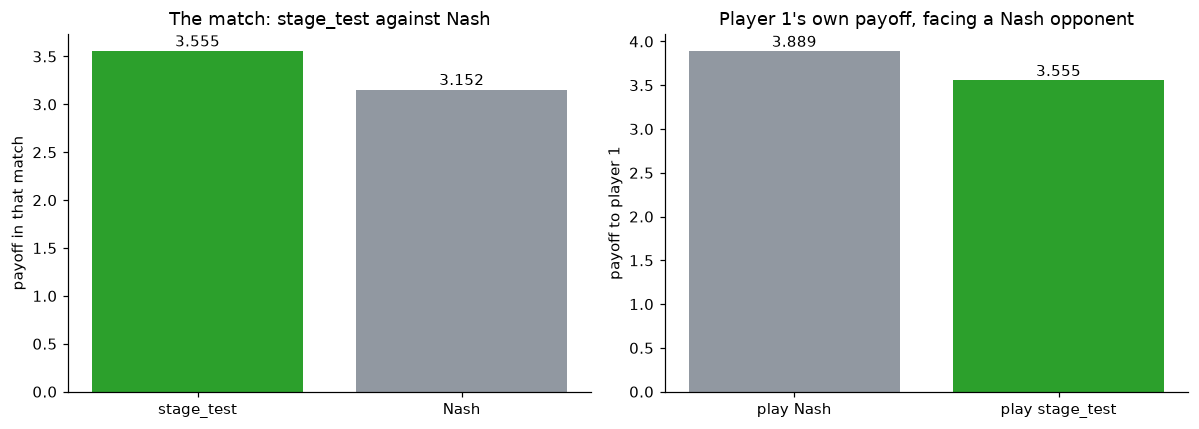

In [9]:
rows = [("Nash against Nash", nash_x @ U1 @ nash_y, nash_x @ U2 @ nash_y),
        ("stage_test against Nash", st_vs_nash, nash_vs_st),
        ("Stackelberg, optimistic", value, lead_x @ U2 @ lead_y)]
print(f"{'':<26}{'player 1':>10}{'player 2':>10}")
for name, a, b in rows:
    print(f"{name:<26}{a:>10.4f}{b:>10.4f}")

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
left.bar(["stage_test", "Nash"], [st_vs_nash, nash_vs_st],
         color=["#2ca02c", "#9198a1"])
left.set_title("The match: stage_test against Nash")
left.set_ylabel("payoff in that match")
for i, v in enumerate([st_vs_nash, nash_vs_st]):
    left.text(i, v + 0.05, f"{v:.3f}", ha="center")

right.bar(["play Nash", "play stage_test"],
          [nash_x @ U1 @ nash_y, stage_test @ U1 @ nash_y],
          color=["#9198a1", "#2ca02c"])
right.set_title("Player 1's own payoff, facing a Nash opponent")
right.set_ylabel("payoff to player 1")
for i, v in enumerate([nash_x @ U1 @ nash_y, stage_test @ U1 @ nash_y]):
    right.text(i, v + 0.05, f"{v:.3f}", ha="center")

fig.tight_layout()
fig.savefig("equilibrium_comparison.png", dpi=110, bbox_inches="tight")
plt.show()

**Left**: the claim, confirmed. `stage_test` outscores Nash when they meet.

**Right**: the cost of it. Against that same opponent, simply playing Nash would
have earned more. The strategy buys a winning margin by giving up absolute
payoff, which is what you want when the margin is what counts and the wrong
thing to want when your own total is.